# RSM6301 Individual Assignment #1: Market Risk

**Student Name:** Mohammad Valizadehmoghadam  

**Student Number:** 1011953511  

**Course:** RSM6301 — Topics of Financial Risk  

**Instructor:** Jun Yuan  

**Date:** April 22, 2026

You are required to answer the questions below for a given portfolio and market data.

A.	The portfolio contains USD equity and fixed income products.
+ Long 30 positions on S&P500 ETF (i.e., SPY)
+ Long 10,000 positions on 10year investment grade (IG) corporate bond with A rating. It has 5% coupon with semi-annual payment.
+	Long 10,000 positions on 2year high yield (HY) corporate bond with BB rating. It has 7% coupon with semi-annual payment.
+	Short 20,000 positions on 5year US Treasury bond. It has 3.875% coupon with semi-annual payment.

    [Note]: Each position has a notional 100 USD.

B.	The spot market data:
+	SPY price (i.e., $380.82)
+	US Risk-free yield curve (i.e., 4.25% @ 2yr, 3.70% @5yr, 3.56% @10yr)
+	Credit spreads for IG and HY (i.e., 112bps for IG A rating, 295bps for HY BB rating)

C.	Time series of market data from 2021 Jan. 4th to 2022 Dec. 29th for SPY price, US risk-free yield curve, credit spreads for IG and HY (see details in file “market data time series.xlsx”).

# Requirements

+ You are required to fill in the missing parts of the Python codes and answer the questions below.
+ Please include documentations and explanations to explain including but not limited to: what your codes do, what steps you took, step by step equations, and what your results mean. You can use any format you like -- markdown, code comments, hand-written pictures, etc.
+ Please add comments in the code when necessary.
+ Please make sure that the output results of your notebook are reproducible by running the whole notebook from the beginning to the end.
+ Please submit on Quercus the completed Jupyter Notebook file (.ipynb) and the html file (exported by running the last cell) of the notebook. You do not need to submit any other files, e.g. the intermediate files exported in the output folder. The TA will run your notebook again and check the output.

# Preparations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
### load dataset
df = pd.read_excel("market data time series.xlsx")
df.head()



,Date,SPY ETF ($),Risk-free Yield @ 10y (%),Risk-free Yield @ 5y (%),Risk-free Yield @ 2y (%),Credit Spread IG (bps),Credit Spread HY (bps)
0,2022-12-29,383.44,3.817,3.942,4.365,108.0,514.331655
1,2022-12-28,376.66,3.885,3.968,4.354,110.0,511.023644
2,2022-12-27,381.40,3.844,3.941,4.377,110.0,491.509226
3,2022-12-23,382.91,3.749,3.858,4.323,109.0,492.298793
4,2022-12-22,380.72,3.681,3.804,4.272,111.0,494.710577


In [3]:
#for my own information
print("-----------------------------------------------------")
print(df.info())
print("-----------------------------------------------------")
print(df.isnull().sum())


-----------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       502 non-null    datetime64[ns]
 1   SPY ETF ($)                502 non-null    float64       
 2   Risk-free Yield @ 10y (%)  502 non-null    float64       
 3   Risk-free Yield @ 5y (%)   502 non-null    float64       
 4   Risk-free Yield @ 2y (%)   502 non-null    float64       
 5   Credit Spread IG (bps)     502 non-null    float64       
 6   Credit Spread HY (bps)     502 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 27.6 KB
None
-----------------------------------------------------
Date                         0
SPY ETF ($)                  0
Risk-free Yield @ 10y (%)    0
Risk-free Yield @ 5y (%)     0
Risk-free Yield @ 2y (%)     0
C

In [4]:
COUPONS = {"IG": 5e-2,
          "HY": 7e-2,
          "UST": 3.875e-2}  # decimal fraction
UST_YIELD = {"10y": 3.56e-2,
             "5y": 3.7e-2,
             "2y": 4.25e-2}  # decimal fraction
CREDIT_SPREAD = {"IG": 112e-4,
                 "HY": 295e-4,
                 "UST": 0}  # decimal fraction
NUM_POSITIONS = {"SPY": 30,
                 "IG": 1e4,
                 "HY": 1e4,
                 "UST": -2e4}
SPY_PRESENT_PRICE = 380.82  # price per unit SPY, USD
COUPON_PAY_FREQ = 2  # twice per year, i.e., semi-annual, for all instrument in portfolio
BOND_NOTIONAL = 100  # notional in USD

In [5]:
### for stress testing in Question 3
CS_SHOCK = {"AAA": 238.9e-4,
            "AA": 266.7e-4,
            "A": 337.6e-4,
            "BBB": 443e-4,
            "BB": 1012e-4,
            "B": 1372.1e-4}  # decimal fraction
UST_SHOCK = {"10y": 49.4e-4,
             "5y": 42.3e-4,
             "2y": 29.9e-4}  # decimal fraction
SPY_SHOCK = -38.3e-2  # decimal fraction

# Question 1: Risk Factor Identification

## 1.1 Identify the risk factors for each instrument in the portfolio.

Please limit your answer within 100 words.

**SPY ETF:** driven by equity price risk. P&L moves directly with SPY spot price.

**IG Corporate Bond (10yr):** exposed to interest rate risk (10yr UST yield) and 
IG credit spread risk. Long duration makes it highly sensitive to rate moves.

**HY Corporate Bond (2yr):** exposed to interest rate risk (2yr UST yield) and 
HY credit spread risk. Short duration but dominated by credit spread volatility.

**US Treasury (5yr, short):** exposed to interest rate risk (5yr UST yield) only, 
no credit spread. Short position means rate increases generate gains.

## 1.2 Calculate the present values per position for each instrument using continuous compounding discounting.

Each bond's present value is computed by discounting all future cash flows 
using **continuous compounding**:

$$PV = \sum_{i=1}^{n} C \cdot e^{-r \cdot t_i} + F \cdot e^{-r \cdot t_n}$$

Where:
- $C$ = coupon payment per period = $\frac{\text{coupon rate} \times \text{notional}}{\text{frequency}}$
- $F$ = face value (notional = \$100)
- $r$ = discount rate = risk-free yield + credit spread (in decimal)
- $t_i$ = time to $i$-th cash flow in years (semi-annual: 0.5, 1.0, 1.5, ...)
- $n$ = total number of periods = maturity (years) × frequency

The eps parameter adds a shock to the discount rate, enabling sensitivity 
calculations (PV01, CS01) via numerical differentiation in Q1.3.

In [6]:
def compute_bond_price(instrument, year, eps=0):
    """
    This function computes the present value per position for a given bond, with a given time to mature.
    :param instrument: bond name
    :param year: time to mature
    :param eps: shock, default is 0. This will be used for sensitivity analysis later.
    :return present value per position
    """

    # Retrieve coupon rate and build discount rate
    # Discount rate = risk-free yield + credit spread (both in decimal)
    # eps shifts the discount rate for sensitivity calculations
    
    coupon_rate = COUPONS[instrument]  # already in decimal (e.g. 0.05)
    
    if instrument == 'IG':
        r = UST_YIELD['10y'] + CREDIT_SPREAD['IG'] + eps
    elif instrument == 'HY':
        r = UST_YIELD['2y'] + CREDIT_SPREAD['HY'] + eps
    elif instrument == 'UST':
        r = UST_YIELD['5y'] + CREDIT_SPREAD['UST'] + eps
    
    # Build cash flow schedule 
    # Semi-annual payments: t = 0.5, 1.0, 1.5, ..., maturity
    coupon_payment = (coupon_rate * BOND_NOTIONAL) / COUPON_PAY_FREQ
    num_periods = int(year * COUPON_PAY_FREQ)  # total number of coupon payments
    times = np.array([i / COUPON_PAY_FREQ for i in range(1, num_periods + 1)])
    
    # Discount each cash flow using continuous compounding 
    # Coupon PV: sum of C * e^(-r * t) for each period
    # Principal PV: F * e^(-r * T) at maturity only
    pv_coupons = np.sum(coupon_payment * np.exp(-r * times))
    pv_principal = BOND_NOTIONAL * np.exp(-r * year)
    
    unit_present_price = pv_coupons + pv_principal
    
    return unit_present_price


In [7]:
present_price_per_position_SPY = SPY_PRESENT_PRICE #no need for discounting
#compute the present value per position for each instrument using continuous compounding
present_price_per_position_IG = compute_bond_price('IG',  year=10)
present_price_per_position_HY = compute_bond_price('HY',  year=2)
present_price_per_position_UST = compute_bond_price('UST',  year=5)

In [8]:
print("Present value per position:")
print("SPY ETF: ${}".format("%.2f" % present_price_per_position_SPY))
print("IG Corporate bond (10 years): ${}".format("%.2f" % present_price_per_position_IG))
print("HY Corporate bond (2 years): ${}".format("%.2f" % present_price_per_position_HY))
print("US Treasury (5 years): ${}".format("%.2f" % present_price_per_position_UST))

Present value per position:
SPY ETF: $380.82
IG Corporate bond (10 years): $102.09
HY Corporate bond (2 years): $99.39
US Treasury (5 years): $100.64


In [9]:
# Export intermediate results for marking... Please do not change or delete this cell
present_price_per_position = {
    "SPY": present_price_per_position_SPY,
    "IG": present_price_per_position_IG,
    "HY": present_price_per_position_HY,
    "UST": present_price_per_position_UST
}
present_price_per_position_df = pd.DataFrame.from_dict(present_price_per_position, orient='index', columns=['Present Price'])
os.makedirs('output', exist_ok=True)
present_price_per_position_df.to_csv('output/Q1_2_present_price_per_position.csv')

## 1.3 Calculate the first-order sensitivity against each risk factor for the portfolio (note, for equity delta use 1% price sensitivity, for PV01 and CS01 use +1bps sensitivities)

## 1.3 First-Order Sensitivities

Sensitivities measure how much the **total portfolio P&L changes** for a small 
shock to each risk factor, computed via numerical differentiation:

$$\text{Sensitivity} = PV(\text{shocked}) - PV(\text{base})$$

Three sensitivities are required:

**Equity Delta** — P&L change for a **+1% move in SPY price**:
$$\Delta_{equity} = \text{positions}_{SPY} \times S_{SPY} \times 1\%$$

**PV01** — P&L change for a **+1 bps parallel shift in risk-free yields**:
$$PV01 = \sum_{\text{bonds}} \left[ PV(r + 0.0001) - PV(r) \right] \times \text{positions}$$

**CS01** — P&L change for a **+1 bps widening in credit spreads**:
$$CS01 = \sum_{\text{credit bonds}} \left[ PV(cs + 0.0001) - PV(cs) \right] \times \text{positions}$$

Note: UST has no credit spread, so it does not contribute to CS01.
Both PV01 and CS01 are expected to be **negative** — rising rates/spreads 
reduce bond prices. The short UST position partially offsets PV01.

In [10]:
def func_shock(instrument, years, eps=0):
  """
  This function computes the total shock for all positions for a given bond, with a given time to mature.
  :param instrument: bond name
  :param years: time to mature
  :param eps: shock 
  :return total shock for all positions
  """
  # Price change per position under the shock
  price_change = compute_bond_price(instrument, years, eps=eps) - \
                 compute_bond_price(instrument, years, eps=0)
    
  # Multiply by number of positions
  total_shock = price_change * NUM_POSITIONS[instrument]
    
  return total_shock

In [11]:
# Equity Delta
# Delta = positions × current price × 1%
equity_delta = NUM_POSITIONS['SPY'] * SPY_PRESENT_PRICE * 0.01

# PV01: P&L impact of +1 bps parallel shift in risk-free yields 
# 1 bps = 0.0001 in decimal; applied to ALL bonds (rates affect everyone)
eps_1bps = 1e-4
PV01 = (func_shock('IG',  years=10, eps=eps_1bps) +
        func_shock('HY',  years=2,  eps=eps_1bps) +
        func_shock('UST', years=5,  eps=eps_1bps))

# CS01: P&L impact of +1 bps widening in credit spreads 
# Only affects credit instruments (IG and HY), not the UST
CS01 = (func_shock('IG', years=10, eps=eps_1bps) +
        func_shock('HY', years=2,  eps=eps_1bps))

In [12]:
print("First-order sensitivity:")
print("Equity Delta: ${}".format("%.2f" % equity_delta))
print("PV01: ${}".format("%.2f" % PV01))
print("CS01: ${}".format("%.2f" % CS01))

First-order sensitivity:
Equity Delta: $114.25
PV01: $-82.05
CS01: $-1006.65


In [13]:
# Export intermediate results for marking... Please do not change or delete this cell
sensitivity = {
    "Equity Delta": equity_delta,
    "PV01": PV01,
    "CS01": CS01
}
sensitivity_df = pd.DataFrame.from_dict(sensitivity, orient='index', columns=['Sensitivity'])
sensitivity_df.to_csv('output/Q1_3_sensitivity.csv')

# Question 2: Internal Risk Management

## 2.1 Generate historical shocks for each risk factor and plot the distribution histogram
assuming the following
+	Historical simulation approach with 2-year window from 2021-1-4 to 2022-12-29. 
+	Equity spot shock is relative, risk-free yield and credit spread shocks are absolute.


Shock conventions:
- **SPY:** *relative* shock — percentage return day-over-day:
$$\delta_{SPY,t} = \frac{S_t - S_{t-1}}{S_{t-1}}$$

- **Rates & Spreads:** *absolute* shock — arithmetic difference:
$$\delta_{r,t} = r_t - r_{t-1}$$

**Unit note:** Yields in the dataset are in % (e.g. 3.817), so the 
absolute difference is already in percentage points. We multiply by 100 
to convert to bps. Credit spreads are already in bps, so we take the 
difference directly.

With 502 data points, we get **501 daily shock scenarios**.

In [14]:
# Sorting by date ascending so that the differences go forward in time
df_sorted = df.sort_values('Date').reset_index(drop=True)

daily_shock_SPY =  df_sorted['SPY ETF ($)'].pct_change().dropna().values# relative shock (percent)
daily_shock_UST_IG_10 = df_sorted['Risk-free Yield @ 10y (%)'].diff().dropna().values * 100 # absolute shock (bps)
daily_shock_UST_5 =  df_sorted['Risk-free Yield @ 5y (%)'].diff().dropna().values  * 100 # absolute shock (bps)
daily_shock_UST_HY_2 = df_sorted['Risk-free Yield @ 2y (%)'].diff().dropna().values  * 100  # absolute shock (bps)
daily_shock_CS_IG =   df_sorted['Credit Spread IG (bps)'].diff().dropna().values # absolute shock (bps)
daily_shock_CS_HY =   df_sorted['Credit Spread HY (bps)'].diff().dropna().values # absolute shock (bps)


print(f"Number of shock scenarios: {len(daily_shock_SPY)}")
print(f"\nSPY shock range:    {daily_shock_SPY.min()*100:.2f}% to {daily_shock_SPY.max()*100:.2f}%")
print(f"UST 10y shock range: {daily_shock_UST_IG_10.min():.2f} to {daily_shock_UST_IG_10.max():.2f} bps")
print(f"CS IG shock range:   {daily_shock_CS_IG.min():.2f} to {daily_shock_CS_IG.max():.2f} bps")
print(f"CS HY shock range:   {daily_shock_CS_HY.min():.2f} to {daily_shock_CS_HY.max():.2f} bps")

Number of shock scenarios: 501

SPY shock range:    -4.35% to 5.50%
UST 10y shock range: -28.10 to 23.70 bps
CS IG shock range:   -9.00 to 7.00 bps
CS HY shock range:   -37.92 to 40.47 bps


In [15]:
# Export intermediate results for marking... Please do not change or delete this cell
daily_shock = {
    "SPY": daily_shock_SPY,
    "UST_10": daily_shock_UST_IG_10,
    "UST_5": daily_shock_UST_5,
    "UST_2": daily_shock_UST_HY_2,
    "CS_IG": daily_shock_CS_IG,
    "CS_HY": daily_shock_CS_HY
}
daily_shock_df = pd.DataFrame.from_dict(daily_shock)
daily_shock_df.to_csv('output/Q2_1_daily_shock.csv', index=False)

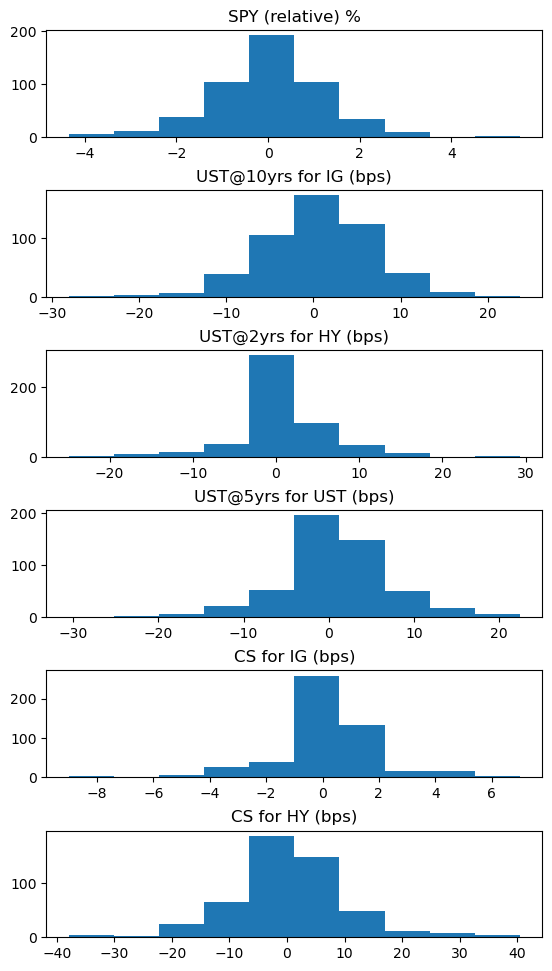

In [16]:
### visualizations (code provided)

plt.figure()
plt.subplots_adjust(top=2, hspace=0.5)

plt.subplot(6,1,1)
plt.hist(daily_shock_SPY * 100)
plt.title("SPY (relative) %")

plt.subplot(6,1,2)
plt.hist(daily_shock_UST_IG_10)
plt.title("UST@10yrs for IG (bps)")

plt.subplot(6,1,3)
plt.hist(daily_shock_UST_HY_2)
plt.title("UST@2yrs for HY (bps)")

plt.subplot(6,1,4)
plt.hist(daily_shock_UST_5)
plt.title("UST@5yrs for UST (bps)")

plt.subplot(6,1,5)
plt.hist(daily_shock_CS_IG)
plt.title("CS for IG (bps)")

plt.subplot(6,1,6)
plt.hist(daily_shock_CS_HY)
plt.title("CS for HY (bps)")


plt.savefig('output/daily_shock_histogram.png', bbox_inches='tight')

plt.show()

## 2.2	Calculate the 1-day Value-at-Risk at 99 percentile confidence level (6th worst) and specify the scenario date together with the scenario risk factor moves. Please use Taylor approach with first-order sensitivities (see chapter 15.11 for definition).

For each of the 501 historical scenarios, we approximate the portfolio P&L 
using the **Taylor (first-order) approach**:

$$\Delta PV \approx \Delta_{equity} \cdot \delta_{SPY} 
+ PV01 \cdot \delta_{r} 
+ CS01 \cdot \delta_{cs}$$

Where each $\delta$ is the historical daily shock for that scenario.

**VaR definition:** With 501 scenarios, the 99% VaR is the **6th worst** 
loss (1% of 501 ≈ 5.01, so the 6th worst scenario is the VaR threshold).

VaR is reported as a **positive number** representing the loss magnitude.

In [17]:
# Date index aligned with shock scenarios 
dates = df_sorted['Date'].iloc[1:].reset_index(drop=True)
# SPY P&L: equity delta × relative shock
# equity_delta is already the $ sensitivity to a 1% move,
# so we scale by (shock / 0.01) to get the actual $ P&L
pnl_SPY = equity_delta * (daily_shock_SPY / 0.01)

# Bond P&L: sensitivity × shock
# PV01/CS01 are per-1bps sensitivities, shocks are in bps
# so pnl = sensitivity × shock_in_bps (no scaling needed)
pnl_IG  = (func_shock('IG',  years=10, eps=eps_1bps) * daily_shock_UST_IG_10 +
           func_shock('IG',  years=10, eps=eps_1bps) * daily_shock_CS_IG)

pnl_HY  = (func_shock('HY',  years=2,  eps=eps_1bps) * daily_shock_UST_HY_2 +
           func_shock('HY',  years=2,  eps=eps_1bps) * daily_shock_CS_HY)

pnl_UST = func_shock('UST', years=5,  eps=eps_1bps) * daily_shock_UST_5

# Portfolio P&L = sum of all instruments
pnl_portfolio = pnl_SPY + pnl_IG + pnl_HY + pnl_UST


In [18]:
### Compute 99th percentile for P&L for each instrument
var99_SPY       = pnl_SPY[np.argsort(pnl_SPY)[5]]
var99_IG        = pnl_IG[np.argsort(pnl_IG)[5]]
var99_HY        = pnl_HY[np.argsort(pnl_HY)[5]]
var99_UST       = pnl_UST[np.argsort(pnl_UST)[5]]
var99_portfolio = pnl_portfolio[np.argsort(pnl_portfolio)[5]]

date_SPY       = dates.iloc[np.argsort(pnl_SPY)[5]].strftime('%Y-%m-%d')
date_IG        = dates.iloc[np.argsort(pnl_IG)[5]].strftime('%Y-%m-%d')
date_HY        = dates.iloc[np.argsort(pnl_HY)[5]].strftime('%Y-%m-%d')
date_UST       = dates.iloc[np.argsort(pnl_UST)[5]].strftime('%Y-%m-%d')
date_portfolio = dates.iloc[np.argsort(pnl_portfolio)[5]].strftime('%Y-%m-%d')

var99 = {
    "SPY":       [var99_SPY, date_SPY],
    "IG":        [var99_IG, date_IG],
    "HY":        [var99_HY, date_HY],
    "UST":       [var99_UST, date_UST],
    "Portfolio": [var99_portfolio, date_portfolio]
}

var99_df = pd.DataFrame.from_dict(var99, orient='index', columns=['99th Percentile', 'Date'])
display(var99_df)

,99th Percentile,Date
SPY,-386.711449,2022-08-26
IG,-13084.336418,2022-03-14
HY,-5602.225093,2022-09-13
UST,-16920.111230,2021-11-26
Portfolio,-9484.750049,2022-02-11


**Portfolio worst day: 2022-02-11**
On February 11, 2022, markets reacted sharply to a hotter-than-expected 
U.S. CPI print (7.5% YoY — the highest since 1982), triggering a broad 
risk-off selloff. SPY fell sharply, IG and HY credit spreads widened, 
and yields spiked. All four risk factors moved against the portfolio 
simultaneously, making this the worst single day in the 2-year window.

**UST worst day: 2021-11-26**
The 5yr Treasury yield dropped sharply on news of the Omicron COVID variant, 
as markets fled to safe-haven assets. Since the portfolio is **short** UST, 
a falling yield (rising bond price) generates a loss on this position.

**IG worst day: 2022-03-14**
Early March 2022 saw aggressive Fed rate hike pricing following Russia's 
invasion of Ukraine and persistent inflation. The 10yr yield spiked 
significantly, crushing the long 10yr IG bond position which has the 
highest duration in the portfolio.

In [19]:
# Export intermediate results for marking... Please do not change or delete this cell
os.makedirs('output', exist_ok=True)
var99_df.to_csv('output/Q2_2_var99.csv')

## 2.3 Calculate the 1-day Expected Shortfall at 97.5 percentile confidence level (top 13 worst scenarios). Please use Taylor approach.

**Expected Shortfall (ES)** basically answers: 
*"Given that we exceed VaR, what is the expected loss?"*

$$ES_{97.5\%} = \frac{1}{k} \sum_{i=1}^{k} L_i$$

Where $L_i$ are the $k$ worst P&L scenarios beyond the 97.5% threshold.

With 501 scenarios: $k = \lfloor 501 \times 2.5\% \rfloor = 13$ worst scenarios.

ES is the **preferred risk measure under Basel III/IV (FRTB)** over VaR because:
- It satisfies subadditivity (portfolio ES ≤ sum of individual ES)
- It captures tail risk
- It penalizes fat-tailed distributions more appropriately

In [20]:
### Compute Expected Shortfall at 97.5 percentile using np.sort or np.percentile

sorted_pnl = np.sort(pnl_portfolio)  # ascending, worst first

ES_975 = np.mean(sorted_pnl[:13])

print("Expected Shortfall at 97.5th percentile: ${:,.0f}".format(ES_975))
print("(Average of the 13 worst daily P&L scenarios)")
print(f"\nFor reference, 99th percentile VaR was: ${var99_portfolio:,.0f}")
print(f"ES/VaR ratio: {ES_975/var99_portfolio:.2f}x")

Expected Shortfall at 97.5th percentile: $-9,974
(Average of the 13 worst daily P&L scenarios)

For reference, 99th percentile VaR was: $-9,485
ES/VaR ratio: 1.05x


In [21]:
# Export intermediate results for marking... Please do not change or delete this cell
expected_shortfall = {
    "Portfolio": ES_975
}
expected_shortfall_df = pd.DataFrame.from_dict(expected_shortfall, orient='index', columns=['Expected Shortfall'])
expected_shortfall_df.to_csv('output/Q2_3_expected_shortfall.csv')

# Question 3: Stress Testing

## 3.1 Given a severely adverse stress scenarios as follows, calculate the P&L loss for each instrument (including position size) and the total portfolio. Please use full revaluation approach.

+ US equity spot price relative shock is -38.3%
+ US risk-free yields are increased by +29.9bps @2yr, 42.30bps @5yr, and 49.40bps @10yr.
+ US credit spread widens by +337.60bps for IG A rating and +1,012bps for HY BB rating.


In **full revaluation**, we reprice every instrument from scratch after 
applying the stress shocks, then compute P&L as:

$$\text{P\&L} = PV(\text{shocked}) - PV(\text{base}) \times \text{positions}$$

The severe adverse scenario applies simultaneous shocks across all risk factors:

| Risk Factor | Shock |
|---|---|
| SPY equity price | -38.3% |
| UST yield @ 2yr | +29.9 bps |
| UST yield @ 5yr | +42.3 bps |
| UST yield @ 10yr | +49.4 bps |
| Credit spread IG (A) | +337.6 bps |
| Credit spread HY (BB) | +1,012 bps |

This scenario approximates a **2008-style financial crisis**: simultaneous 
equity crash, credit crisis, and rate spike. Full revaluation captures 
**convexity effects** that Taylor approximation misses.

In [22]:
# SPY: full revaluation
SPY_shocked_price = SPY_PRESENT_PRICE * (1 + SPY_SHOCK)
SPY_shock_full_reval = (SPY_shocked_price - SPY_PRESENT_PRICE) * NUM_POSITIONS['SPY']

# Bonds: func_shock with combined rate + credit spread shock
IG_shock_full_reval  = func_shock('IG',  years=10, eps=UST_SHOCK['10y'] + CS_SHOCK['A'])
HY_shock_full_reval  = func_shock('HY',  years=2,  eps=UST_SHOCK['2y']  + CS_SHOCK['BB'])
UST_shock_full_reval = func_shock('UST', years=5,  eps=UST_SHOCK['5y'])

# Portfolio total
portfolio_shock_full_reval = (SPY_shock_full_reval + IG_shock_full_reval + 
                               HY_shock_full_reval + UST_shock_full_reval)

In [23]:
full_reval = {
    "SPY": SPY_shock_full_reval,
    "IG": IG_shock_full_reval,
    "HY": HY_shock_full_reval,
    "UST": UST_shock_full_reval,
    "Portfolio": portfolio_shock_full_reval
}
full_reval_df = round(pd.DataFrame.from_dict(full_reval, orient='index', columns=['Stress Testing P&L (Full Reval)']), 2)

display(full_reval_df)

,Stress Testing P&L (Full Reval)
SPY,-4375.62
IG,-266659.59
HY,-178057.34
UST,38722.01
Portfolio,-410370.54


In [24]:
# Export intermediate results for marking... Please do not change or delete this cell
full_reval_df.to_csv('output/Q3_1_stress_testing_full_reval.csv')

## 3.2 Repeat the calculation in 3.1 using Taylor based approach.

Using first-order sensitivities scaled by the stress shock magnitudes:

$$\Delta PV \approx \Delta_{equity} \cdot \delta_{SPY} + PV01 \cdot \delta_{r} + CS01 \cdot \delta_{cs}$$

**NOTE** : Taylor's linear approximation will underestimate losses due to bond convexity.

In [25]:
### compute profit and loss (P&L), Taylor approach

# SPY: Taylor (same as full reval for equity — linear by nature)
SPY_shock_taylor = equity_delta * (SPY_SHOCK / 0.01)

# Bonds: sensitivity × shock in bps
# Rate shock component (PV01 × rate shock)
IG_shock_taylor  = (func_shock('IG',  years=10, eps=eps_1bps) * UST_SHOCK['10y']  * 1e4 +
                    func_shock('IG',  years=10, eps=eps_1bps) * CS_SHOCK['A']     * 1e4)

HY_shock_taylor  = (func_shock('HY',  years=2,  eps=eps_1bps) * UST_SHOCK['2y']   * 1e4 +
                    func_shock('HY',  years=2,  eps=eps_1bps) * CS_SHOCK['BB']    * 1e4)

UST_shock_taylor = func_shock('UST', years=5,  eps=eps_1bps) * UST_SHOCK['5y']   * 1e4

# Portfolio total
portfolio_shock_taylor = (SPY_shock_taylor + IG_shock_taylor + 
                          HY_shock_taylor  + UST_shock_taylor)

In [26]:
taylor = {
    "SPY": SPY_shock_taylor,
    "IG": IG_shock_taylor,
    "HY": HY_shock_taylor,
    "UST": UST_shock_taylor,
    "Portfolio": portfolio_shock_taylor
}
taylor_df = round(pd.DataFrame.from_dict(taylor, orient='index', columns=['Stress Testing P&L (Taylor)']), 2)
display(taylor_df)


,Stress Testing P&L (Taylor)
SPY,-4375.62
IG,-316477.39
HY,-196791.79
UST,39110.42
Portfolio,-478534.37


In [27]:
# Export intermediate results for marking... Please do not change or delete this cell
taylor_df.to_csv('output/Q3_2_stress_testing_taylor.csv')

## 3.3 Compare the results of full revaluation and Taylor's approach in stress testing P&L calculation. Which one is better? 
Please limit your answer within 100 words.


Taylor **overstates** the portfolio loss (-$478,534 vs. -$410,371 full reval, 
a 16.6% difference). This occurs because Taylor uses a **linear approximation** 
of the price-yield relationship, ignoring **convexity** — bonds exhibit positive 
convexity, meaning price declines slow as yields rise. Taylor misses this 
cushioning effect, overstating losses for large shocks. Full revaluation 
reprices each instrument using the actual pricing model, capturing convexity 
correctly. For stress testing with large shocks, **full revaluation is always 
preferred**. Taylor is appropriate only for small, incremental moves in 
day-to-day risk monitoring.

# Question 4: Comparison and Risk Limits

## 4.1 Compare the risk measures from IRM (i.e., VaR and ES) and ST (i.e., P&L loss), and discuss your observations.

Please limit your answer within 100 words.

| Measure | Value |
|---|---|
| 99% VaR (1-day) | -$9,485 |
| ES 97.5% (1-day) | -$9,974 |
| Stress Test P&L (Full Reval) | -$410,371 |

The stress loss is **43x larger** than VaR. This gap exists because VaR/ES 
are **statistically-driven** and bounded by what historically occurred in the 
2021-2022 window (not a stressfull timezone) while stress testing applies **hypothetical extreme shocks** that 
may never appear in historical data. VaR also assumes normal market 
functioning, while stress scenarios model simultaneous multi-factor crises. 
The two measures are **complementary**: VaR captures day-to-day tail risk; 
stress testing captures existential, crisis-level losses.

## 4.2 If you are a risk manager for this portfolio, how you will setup risk limits and why?

Please limit your answer within 200 words.

If I were managing this portfolio, I would build limits around three layers:

- The first is a **VaR limit of 15,000 USD** (1-day, 99%). Our current VaR sits at 9,485 USD, so this gives reasonable breathing room for normal market moves while still flagging anything unusual. A breach would trigger a mandatory position review before any new trades.

- The second is a **stress loss limit of 500,000 USD**. Our full revaluation stress P&L came in at 410,371 USD, so this cap ensures we stay within a manageable range under a crisis scenario while still aligning with Basel III's expectation that banks hold capital against extreme events.

- The third layer is **sensitivity limits**. Looking at our Greeks, credit spread risk is clearly the dominant exposure with a CS01 of 1,007 USD per bps, far exceeding our PV01 of 82 USD. I would set the tightest limit here, around 1,500 USD CS01, because the IG bond alone drives roughly 65% of our stress loss and there is no credit hedge in this portfolio. PV01 and equity delta have much more headroom given current levels.

In [28]:
import subprocess

subprocess.run([
    'jupyter', 'nbconvert', 
    '--to', 'html', 
    'MR_starter.ipynb'
], check=True)

print("HTML exported successfully: MR_starter.html")

[NbConvertApp] Converting notebook MR_starter.ipynb to html


HTML exported successfully: MR_starter.html


[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 443760 bytes to MR_starter.html
